<a href="https://colab.research.google.com/github/paritagala/ALY6120---Group-3/blob/main/Copy_of_Sensitivity_Analysis_Using_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For the following project, use simulation to conduct a sensitivity analysis on the effect of each task's duration on the overall project duration


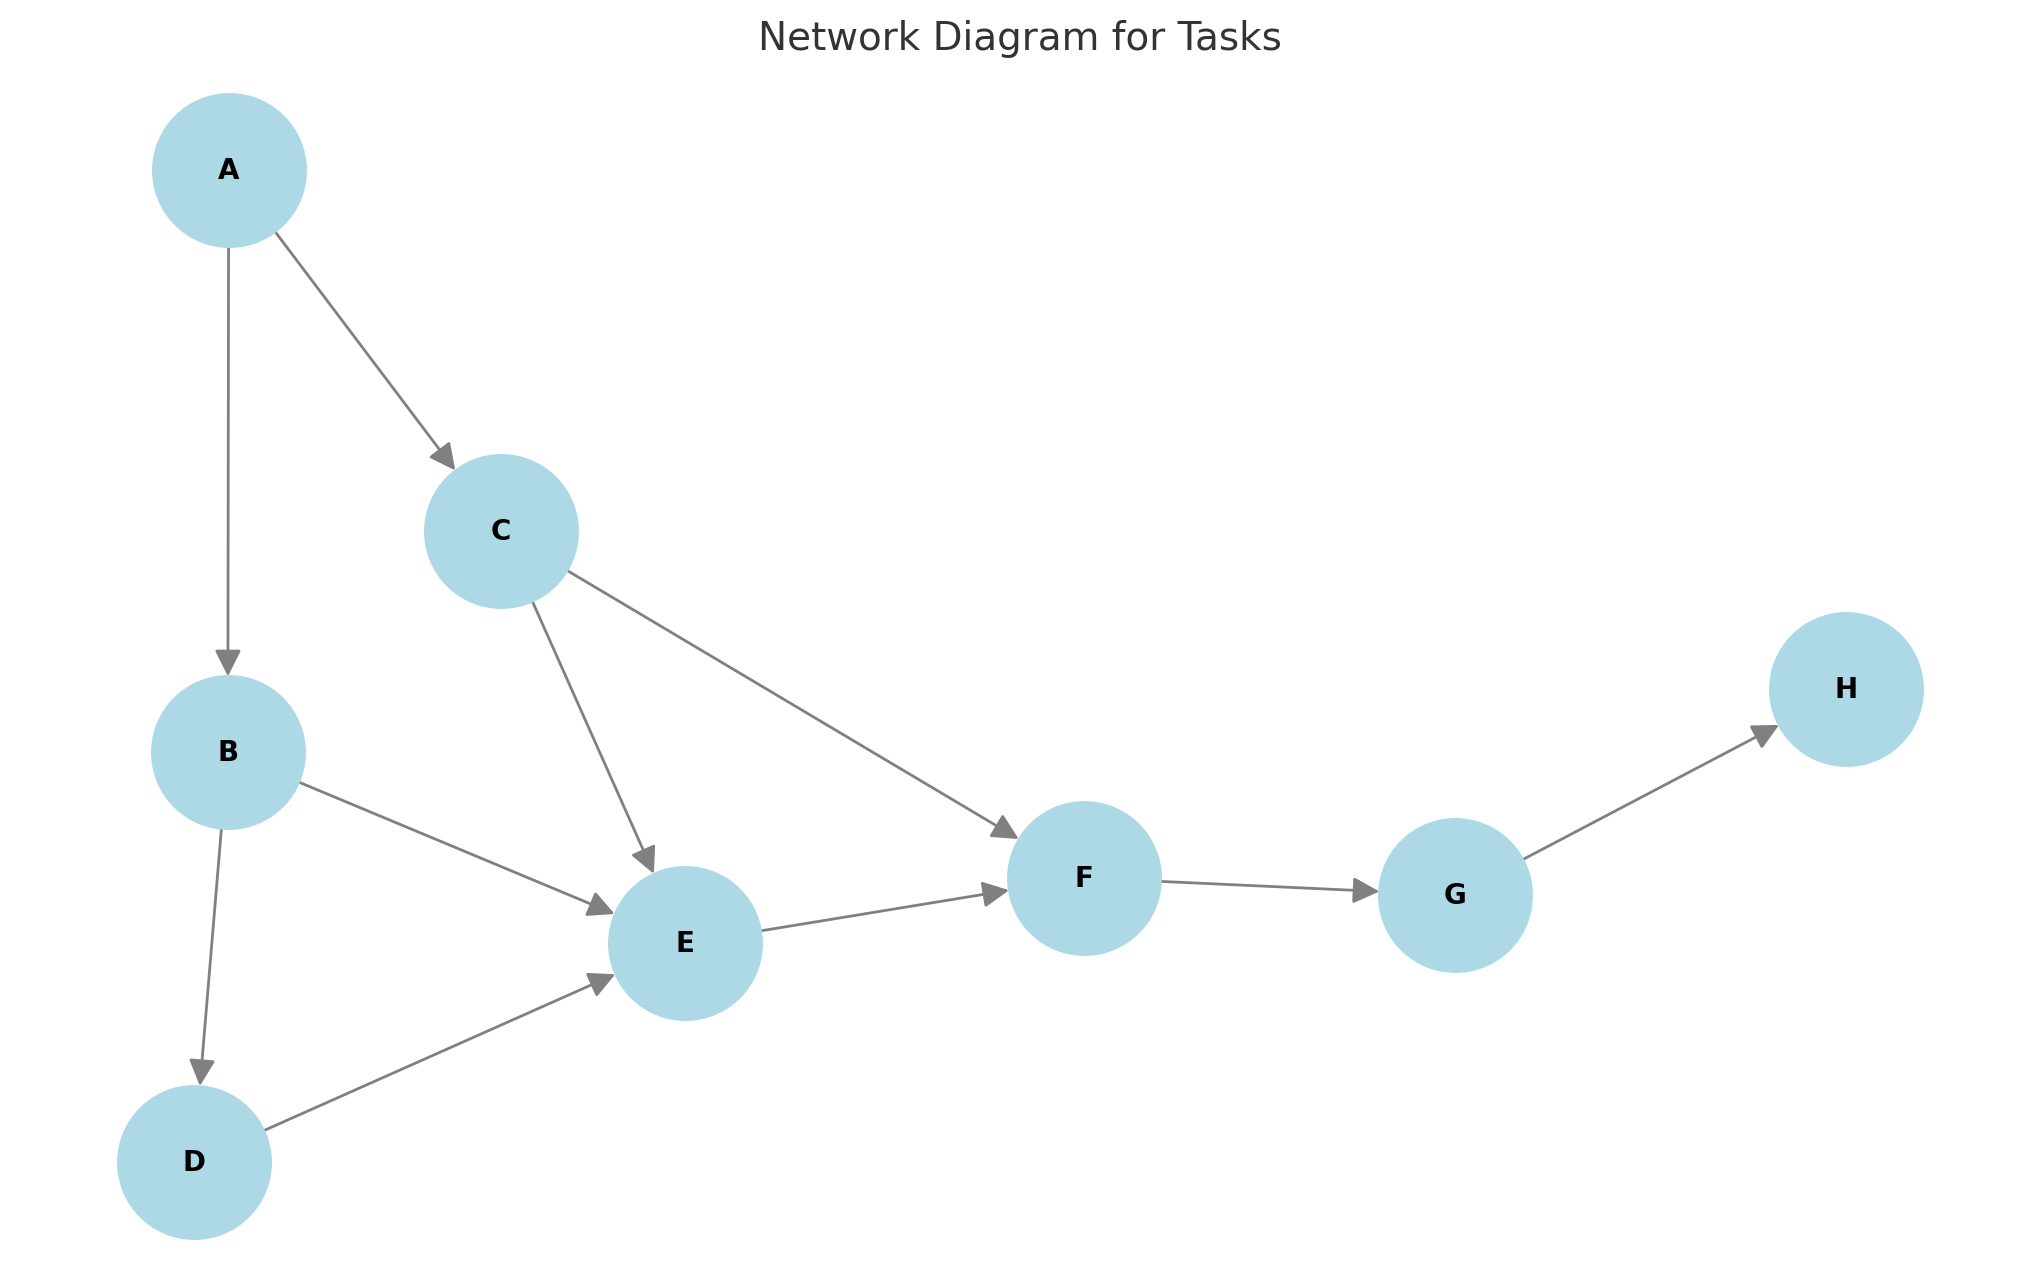

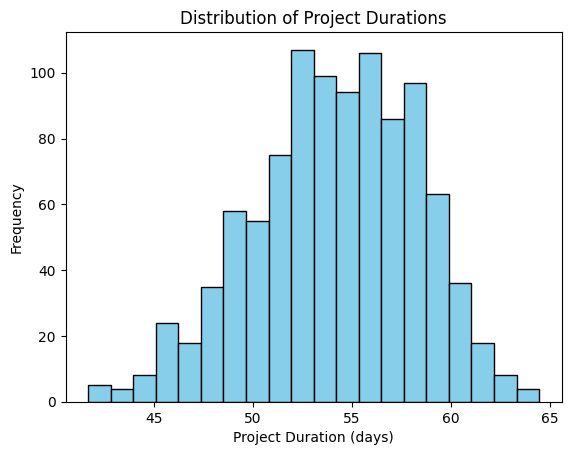

Average Project Duration: 54.17 days


,Task,Avg Duration,Min Duration,Max Duration,Avg ES,Avg EF,Avg LS,Avg LF,Avg Slack
0,A,4.811335,2.155709,6.241968,0.000000,4.811335,1.167955e-16,4.811335,0.000
1,B,10.318012,4.110821,13.379976,4.811335,15.129347,1.238371e+01,22.701723,7.573
2,C,20.832984,15.488161,23.751633,4.811335,25.644319,4.811335e+00,25.644319,0.000
3,D,2.942596,2.037990,3.413645,15.129347,18.071943,2.270172e+01,25.644319,7.573
4,E,7.145463,5.197691,8.158944,25.644319,32.789782,2.564432e+01,32.789782,0.000
5,F,11.939288,4.209821,15.945715,32.789782,44.729070,3.278978e+01,44.729070,0.000
6,G,7.486951,3.141992,9.707335,44.729070,52.216021,4.472907e+01,52.216021,0.000
7,H,1.952975,1.023358,2.413586,52.216021,54.168996,5.221602e+01,54.168996,0.000


In [2]:
# run CPM and PERT

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

random.seed(101)

num_simulations = 1000

tasks = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

predecessors = {
    'A': [],
    'B': ['A'],
    'C': ['A'],
    'D': ['B'],
    'E': ['B', 'C', 'D'],
    'F': ['C', 'E'],
    'G': ['F'],
    'H': ['G']
}

durations = {'A': (2, 5, 8), 'B': (4, 12, 15), 'C': (15, 22, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}

followers = {task: [] for task in predecessors}

for task, preds in predecessors.items():
    for predecessor in preds:
        followers[predecessor].append(task)

def run_simulation(num_simulations, durations):

  total_durations = []
  all_metrics = []
  all_durations = {task: [] for task in tasks}
  all_es = {task: [] for task in tasks}
  all_ef = {task: [] for task in tasks}
  all_ls = {task: [] for task in tasks}
  all_lf = {task: [] for task in tasks}
  all_slack = {task: [] for task in tasks}

  for i in range(num_simulations):

      activity_durations = {task: random.triangular(durations[task][0], durations[task][1], durations[task][2]) for task in durations}

      visited_tasks = []

      early_start = {}
      early_finish = {}

      for task in [task for task, preds in predecessors.items() if not preds]:
          early_start[task] = 0
          early_finish[task] = early_start[task] + activity_durations[task]
          visited_tasks.append(task)

      for task in visited_tasks:
          for follower in followers[task]:
              if (follower not in visited_tasks) and all(x in visited_tasks for x in predecessors[follower]):
                  early_start[follower] = max([early_finish[pred] for pred in predecessors[follower]])
                  early_finish[follower] = early_start[follower] + activity_durations[follower]
                  visited_tasks.append(follower)

      visited_tasks = []

      late_start = {}
      late_finish = {}

      for task in [task for task, fols in followers.items() if not fols]:
          late_finish[task] = early_finish[task]
          late_start[task] = late_finish[task] - activity_durations[task]
          visited_tasks.append(task)

      for task in visited_tasks:
          for predecessor in predecessors[task]:
            if (predecessor not in visited_tasks) and all(x in visited_tasks for x in followers[predecessor]):
              late_finish[predecessor] = min([late_start[fol] for fol in followers[predecessor]])
              late_start[predecessor] = late_finish[predecessor] - activity_durations[predecessor]
              visited_tasks.append(predecessor)

      slack = {task: round(late_start[task] - early_start[task], 1) for task in durations}

      all_metrics.append({'Duration': activity_durations, 'ES': early_start, 'EF': early_finish, 'LS': late_start, 'LF': late_finish, 'Slack': slack})

      for task in tasks:
          all_durations[task].append(activity_durations.get(task, 0))
          all_es[task].append(early_start.get(task, 0))
          all_ef[task].append(early_finish.get(task, 0))
          all_ls[task].append(late_start.get(task, 0))
          all_lf[task].append(late_finish.get(task, 0))
          all_slack[task].append(slack.get(task, 0))

      total_durations.append(max(early_finish.values()))

  avg_es = {task: np.mean(times) for task, times in all_es.items()}
  avg_ef = {task: np.mean(times) for task, times in all_ef.items()}
  avg_ls = {task: np.mean(times) for task, times in all_ls.items()}
  avg_lf = {task: np.mean(times) for task, times in all_lf.items()}
  avg_slack = {task: np.mean(times) for task, times in all_slack.items()}

  avg_duration = {task: np.mean(times) for task, times in all_durations.items()}
  min_duration = {task: np.min(times) for task, times in all_durations.items()}
  max_duration = {task: np.max(times) for task, times in all_durations.items()}

  df = pd.DataFrame({
      'Task': tasks,
      'Avg Duration': [avg_duration[task] for task in tasks],
      'Min Duration': [min_duration[task] for task in tasks],
      'Max Duration': [max_duration[task] for task in tasks],
      'Avg ES': [avg_es[task] for task in tasks],
      'Avg EF': [avg_ef[task] for task in tasks],
      'Avg LS': [avg_ls[task] for task in tasks],
      'Avg LF': [avg_lf[task] for task in tasks],
      'Avg Slack': [avg_slack[task] for task in tasks]
  })

  return df, total_durations

df, total_durations = run_simulation(num_simulations, durations)

plt.hist(total_durations, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Project Durations')
plt.xlabel('Project Duration (days)')
plt.ylabel('Frequency')
plt.show()

avg_proj_duration = np.mean(total_durations)
print(f'Average Project Duration: {avg_proj_duration:.2f} days')


df


In [3]:
# sensitivity analysis

min_proj_durations = {task: [] for task in tasks}
max_proj_durations = {task: [] for task in tasks}

avg_proj_duration_original = avg_proj_duration

num_simulations = 1000

for task in tasks:

    durations2 = durations.copy()

    min_value = min(durations[task])

    durations2[task] = (min_value, min_value, min_value)

    print(durations2)

    df2, total_durations = run_simulation(num_simulations, durations2)

    avg_proj_duration = np.mean(total_durations)

    min_proj_durations[task].append(avg_proj_duration)

    durations2 = durations.copy()
    df2 = df.copy()
    df2 = df2.set_index('Task')['Max Duration'].to_dict()

    durations2 = durations.copy()

    max_value = max(durations[task])

    durations2[task] = (max_value, max_value, max_value)

    print(durations2)

    df2, total_durations = run_simulation(num_simulations, durations2)

    avg_proj_duration = np.mean(total_durations)

    max_proj_durations[task].append(avg_proj_duration)

df2 = pd.DataFrame({
    'Task': tasks,
    'Avg Min Project Duration': [min_proj_durations[task][0] for task in tasks],
    'Avg Max Project Duration': [max_proj_durations[task][0] for task in tasks],
})

df2



{'A': (2, 2, 2), 'B': (4, 12, 15), 'C': (15, 22, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (8, 8, 8), 'B': (4, 12, 15), 'C': (15, 22, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (4, 4, 4), 'C': (15, 22, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (15, 15, 15), 'C': (15, 22, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (4, 12, 15), 'C': (15, 15, 15), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (4, 12, 15), 'C': (26, 26, 26), 'D': (2, 3, 4), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (4, 12, 15), 'C': (15, 22, 26), 'D': (2, 2, 2), 'E': (5, 7, 10), 'F': (4, 15, 17), 'G': (3, 8, 12), 'H': (1, 2, 3)}
{'A': (2, 5, 8), 'B': (4, 12, 15), 

,Task,Avg Min Project Duration,Avg Max Project Duration
0,A,51.308192,57.300464
1,B,54.118291,54.251351
2,C,48.590223,59.222904
3,D,54.204835,54.200914
4,E,51.941164,57.026875
5,F,46.321118,59.246467
6,G,49.707547,58.810715
7,H,53.367899,55.390580


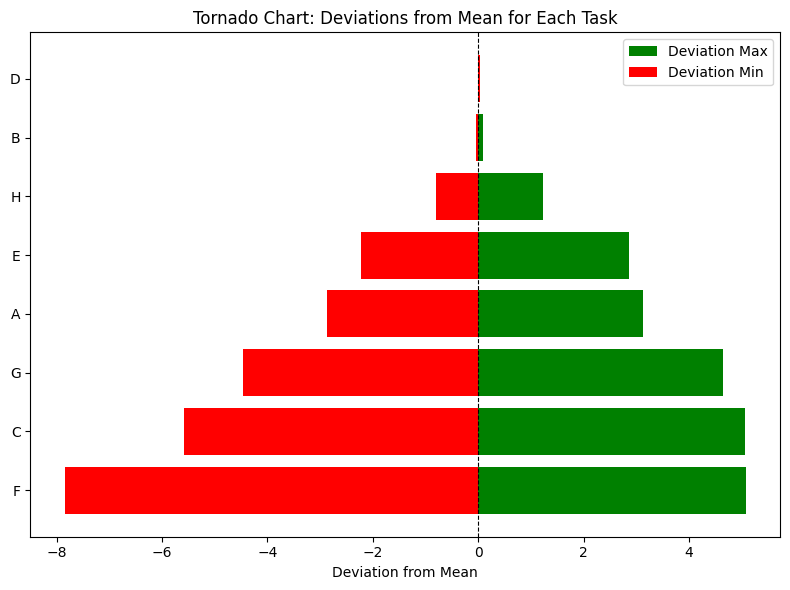

,Task,Avg Min Project Duration,Avg Max Project Duration,Original Avg Project Duration,Deviation Min,Deviation Max,Max Absolute Deviation
5,F,46.321118,59.246467,54.168996,-7.847879,5.077471,12.925350
2,C,48.590223,59.222904,54.168996,-5.578774,5.053908,10.632682
6,G,49.707547,58.810715,54.168996,-4.461449,4.641719,9.103168
0,A,51.308192,57.300464,54.168996,-2.860804,3.131468,5.992272
4,E,51.941164,57.026875,54.168996,-2.227832,2.857879,5.085712
7,H,53.367899,55.390580,54.168996,-0.801097,1.221583,2.022680
1,B,54.118291,54.251351,54.168996,-0.050706,0.082355,0.133060
3,D,54.204835,54.200914,54.168996,0.035839,0.031917,-0.003922


In [4]:
# tornado chart

df2['Original Avg Project Duration'] = avg_proj_duration_original
df2['Deviation Min'] = df2['Avg Min Project Duration'] - avg_proj_duration_original
df2['Deviation Max'] = df2['Avg Max Project Duration'] - avg_proj_duration_original

df2['Max Absolute Deviation'] = df2['Deviation Max'] - df2['Deviation Min']
df2 = df2.sort_values(by='Max Absolute Deviation', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(df))
ax.barh(y_pos, df2['Deviation Max'], color='green', label='Deviation Max')
ax.barh(y_pos, df2['Deviation Min'], color='red', label='Deviation Min')

ax.set_yticks(y_pos)
ax.set_yticklabels(df2['Task'])
ax.set_xlabel('Deviation from Mean')
ax.set_title('Tornado Chart: Deviations from Mean for Each Task')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()

plt.tight_layout()
plt.show()

df2
